In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models


In [2]:
df = pd.read_csv("final_combined_data.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Ticker,Return,Volatility,Volume_Zscore,Return_Zscore,Manipulation_Flag,stock,sentiment_score,risk_score,event_count,twitter_sentiment
0,2018-01-02,39.986349,40.489233,39.774854,40.479832,102223600,AAPL,NaN,NaN,-0.092570,NaN,0,AAPL,0.5,1.0,0.0,0.5
1,2018-01-03,40.543277,41.017963,40.409333,40.472778,118071600,AAPL,-0.000174,NaN,0.194878,-0.070361,0,AAPL,0.5,1.0,0.0,0.5
2,2018-01-04,40.545623,40.764168,40.437528,40.660770,89738400,AAPL,0.004645,NaN,-0.319025,0.171144,0,AAPL,0.5,1.0,0.0,0.5
3,2018-01-05,40.757138,41.210672,40.665491,41.123726,94640000,AAPL,0.011386,NaN,-0.230121,0.508955,0,AAPL,0.5,1.0,0.0,0.5
4,2018-01-08,40.970982,41.267071,40.872282,40.970982,82271200,AAPL,-0.003714,NaN,-0.454464,-0.247764,0,AAPL,0.5,1.0,0.0,0.5


In [3]:
df['Return'] = df['Return'].fillna(0)
df['Volatility'] = df.groupby('stock')['Volatility'].transform(
    lambda x: x.fillna(x.median())
)
df['Return_Zscore'] = df['Return_Zscore'].fillna(0)

In [4]:
print("\nMissing Values per Column:\n", df.isnull().sum())


Missing Values per Column:
 Date                 0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Ticker               0
Return               0
Volatility           0
Volume_Zscore        0
Return_Zscore        0
Manipulation_Flag    0
stock                0
sentiment_score      0
risk_score           0
event_count          0
twitter_sentiment    0
dtype: int64


Manipulation_Flag
0    12236
1       60
Name: count, dtype: int64


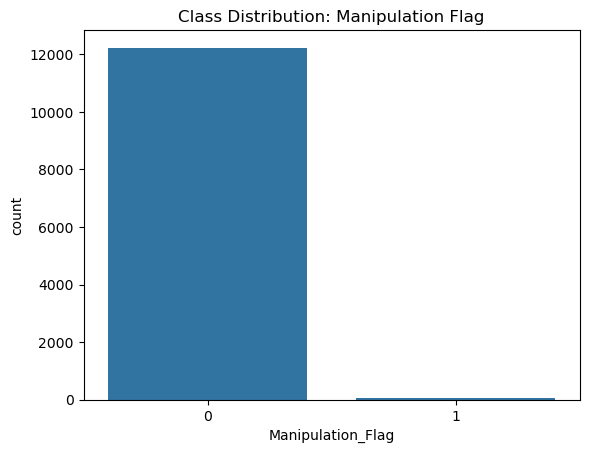

In [5]:
print(df['Manipulation_Flag'].value_counts())
sns.countplot(x='Manipulation_Flag', data=df)
plt.title('Class Distribution: Manipulation Flag')
plt.show()

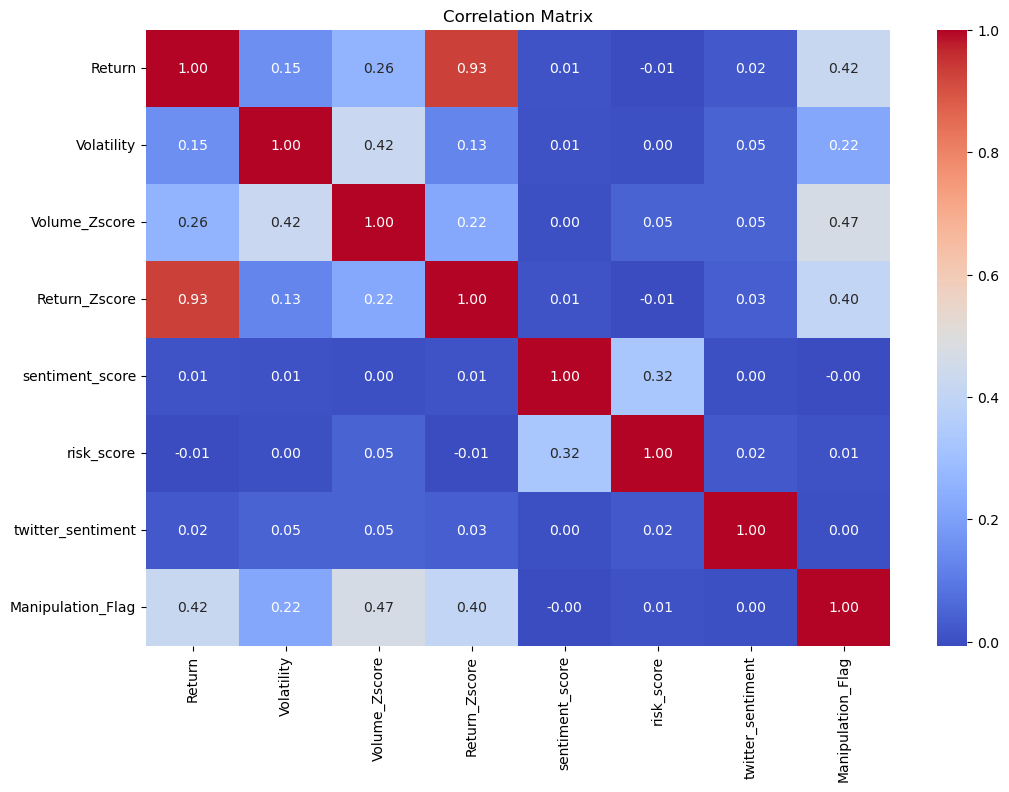

In [7]:
numeric_cols = ['Return', 'Volatility', 'Volume_Zscore', 'Return_Zscore', 'sentiment_score', 'risk_score', 'twitter_sentiment']

plt.figure(figsize=(12,8))
corr = df[numeric_cols + ['Manipulation_Flag']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

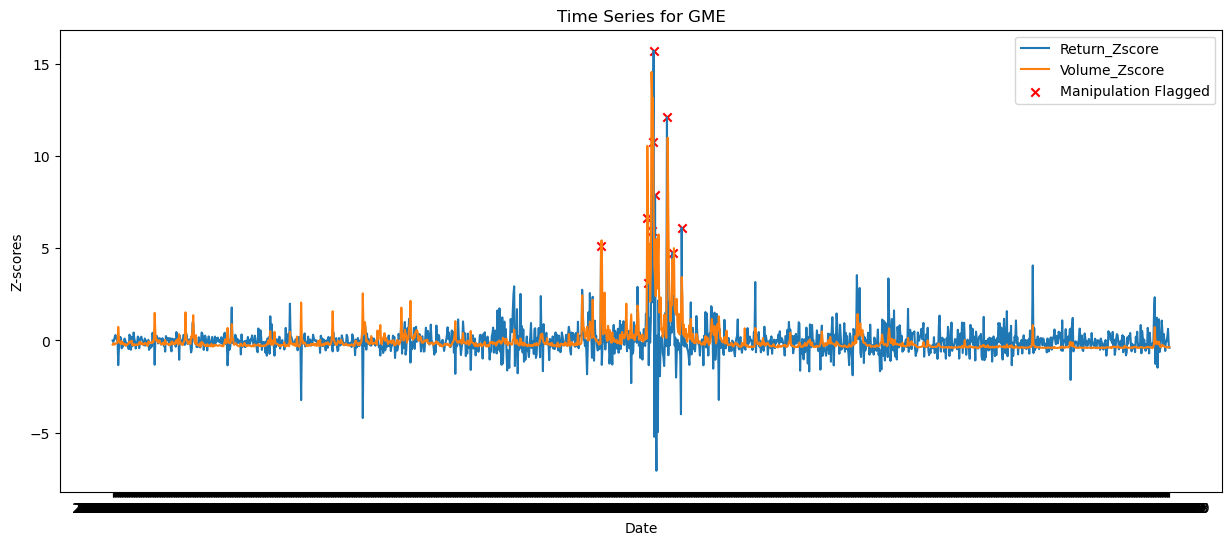

In [8]:
sample_stock = 'GME'
sample_df = df[df['stock'] == sample_stock]

plt.figure(figsize=(15,6))
plt.plot(sample_df['Date'], sample_df['Return_Zscore'], label='Return_Zscore')
plt.plot(sample_df['Date'], sample_df['Volume_Zscore'], label='Volume_Zscore')
plt.scatter(sample_df['Date'][sample_df['Manipulation_Flag']==1],
            sample_df['Return_Zscore'][sample_df['Manipulation_Flag']==1],
            color='red', label='Manipulation Flagged', marker='x')
plt.legend()
plt.title(f'Time Series for {sample_stock}')
plt.xlabel('Date')
plt.ylabel('Z-scores')
plt.show()

In [9]:
# df['Manipulation_Flag_extended'] = (
#     ((df['Return_Zscore'] > 3) & (df['Volume_Zscore'] > 3)) &
#     ((df['twitter_sentiment'] > 0.7) | (df['twitter_sentiment'] < 0.3) | (df['risk_score'] >= 2))
# ).astype(int)

In [10]:
# print(df['Manipulation_Flag_extended'].value_counts())

In [11]:
# df[df['Manipulation_Flag_extended'] == 1]

In [13]:
X = df.drop(columns=['Date', 'stock', 'Ticker'])  # drop non-feature columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
iso = IsolationForest(n_estimators=100, contamination=0.005, random_state=42)
iso.fit(X_scaled)
iso_scores = -iso.decision_function(X_scaled)  # higher means more anomalous

df['iso_anomaly_score'] = iso_scores
df

,Date,Open,High,Low,Close,Volume,Ticker,Return,Volatility,Volume_Zscore,Return_Zscore,Manipulation_Flag,stock,sentiment_score,risk_score,event_count,twitter_sentiment,iso_anomaly_score
0,2018-01-02,39.986349,40.489233,39.774854,40.479832,102223600,AAPL,0.000000,0.014841,-0.092570,0.000000,0,AAPL,0.5,1.0,0.0,0.5,-0.350124
1,2018-01-03,40.543277,41.017963,40.409333,40.472778,118071600,AAPL,-0.000174,0.014841,0.194878,-0.070361,0,AAPL,0.5,1.0,0.0,0.5,-0.341177
2,2018-01-04,40.545623,40.764168,40.437528,40.660770,89738400,AAPL,0.004645,0.014841,-0.319025,0.171144,0,AAPL,0.5,1.0,0.0,0.5,-0.356632
3,2018-01-05,40.757138,41.210672,40.665491,41.123726,94640000,AAPL,0.011386,0.014841,-0.230121,0.508955,0,AAPL,0.5,1.0,0.0,0.5,-0.348575
4,2018-01-08,40.970982,41.267071,40.872282,40.970982,82271200,AAPL,-0.003714,0.014841,-0.454464,-0.247764,0,AAPL,0.5,1.0,0.0,0.5,-0.351248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12291,2023-12-22,0.211000,0.220000,0.210000,0.217600,4682395,ZOM,0.003690,0.076343,-0.300652,0.032187,0,ZOM,0.5,1.0,0.0,0.5,-0.361189
12292,2023-12-26,0.216800,0.228500,0.214500,0.221900,9352873,ZOM,0.019761,0.072518,-0.210634,0.240736,0,ZOM,0.5,1.0,0.0,0.5,-0.359555
12293,2023-12-27,0.222500,0.228400,0.211000,0.215000,5095105,ZOM,-0.031095,0.078142,-0.292697,-0.419208,0,ZOM,0.5,1.0,0.0,0.5,-0.361058
12294,2023-12-28,0.216000,0.218200,0.207000,0.210000,4325280,ZOM,-0.023256,0.066950,-0.307534,-0.317481,0,ZOM,0.5,1.0,0.0,0.5,-0.362845


In [15]:
input_dim = X_scaled.shape[1]
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=256, validation_split=0.1, verbose=0)

reconstructions = autoencoder.predict(X_scaled)
reconstruction_errors = np.mean(np.square(X_scaled - reconstructions), axis=1)

df['autoencoder_error'] = reconstruction_errors

top_anomalies = df.sort_values('autoencoder_error', ascending=False).head(10)
print(top_anomalies[['Date', 'stock', 'autoencoder_error', 'iso_anomaly_score']])

385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step
             Date stock  autoencoder_error  iso_anomaly_score
11377  2020-05-07   ZOM           0.366653          -0.022527
8333   2020-03-31  TLRY           0.156906          -0.157430
8516   2020-12-18  TLRY           0.130621          -0.112891
2281   2021-01-27   AMC           0.106946           0.035206
8029   2019-01-15  TLRY           0.101710          -0.048658
11416  2020-07-02   ZOM           0.100666          -0.058299
9005   2022-11-29  TLRY           0.098331          -0.100144
8291   2020-01-30  TLRY           0.088943          -0.118892
3882   2021-06-09   GME           0.083334          -0.130442
4640   2021-06-09  GOEV           0.082584          -0.018584
